# 🫀 Heart Disease Prediction
## A Machine Learning Model for Cardiac Risk Classification

This project aims to build a classification model capable of predicting 
whether a patient is at risk of heart disease based on clinical features.

**Dataset:** UCI Heart Disease Data  
**Algorithm:** Random Forest Classifier  
**Evaluation Metrics:** Accuracy, Recall, F1-Score and Confusion Matrix

## Cleaning data

### 1. Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, confusion_matrix, classification_report)

from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

### 2. Loading the Data

In [11]:
df = pd.read_csv('data/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 3. Exploratory Analysis
Before cleaning the data, the dataset structure and missing values were examined.

In [12]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()
print(df.info())

Rows: 920
Columns: 16

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None


In [13]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

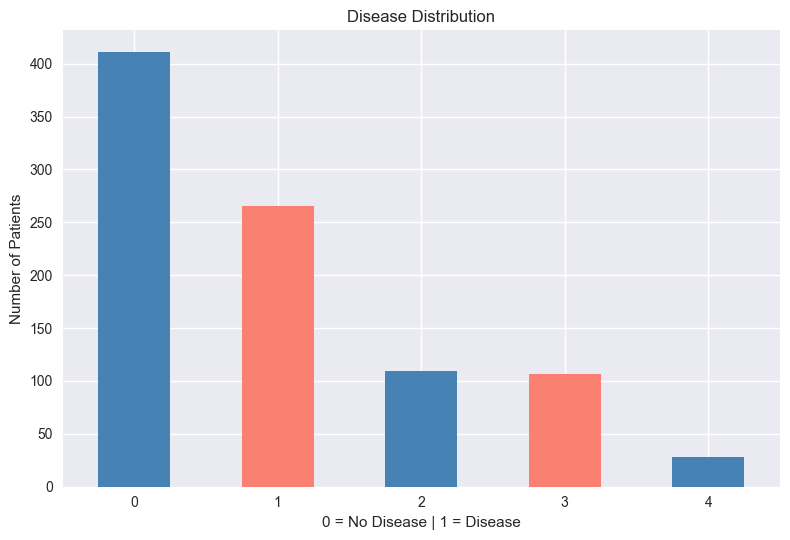

In [14]:
# Disease distribution
df['num'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Disease Distribution')
plt.xlabel('0 = No Disease | 1 = Disease')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

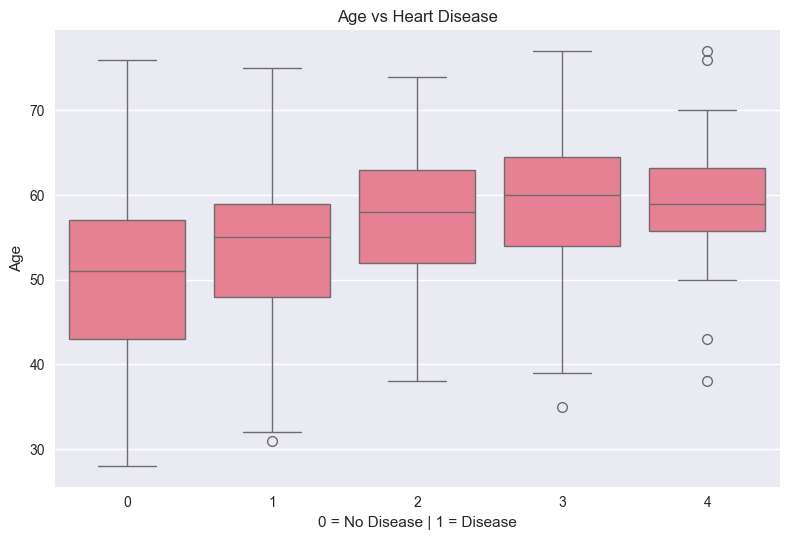

In [15]:
# Age vs Disease
sns.boxplot(x='num', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.xlabel('0 = No Disease | 1 = Disease')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

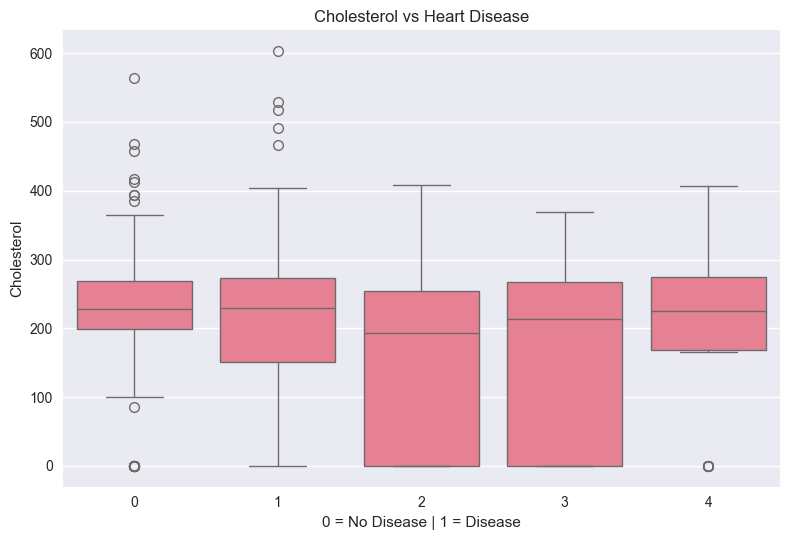

In [16]:
# Cholesterol vs Disease
sns.boxplot(x='num', y='chol', data=df)
plt.title('Cholesterol vs Heart Disease')
plt.xlabel('0 = No Disease | 1 = Disease')
plt.ylabel('Cholesterol')
plt.tight_layout()
plt.show()

#### Key Findings from Exploratory Analysis

- The dataset is slightly imbalanced, with more patients diagnosed with heart disease than without.
- Patients with heart disease tend to be older, with a median age approximately 6 years higher than patients without disease.
- Cholesterol levels show similar distributions across both groups when analyzed in isolation. However, the Random Forest model identified it as the strongest predictor, suggesting it acts in combination with other clinical variables.

### 4. Data Cleaning  
After checking for missing values, the following decisions were made:

- **Columns with few missing values** (`trestbps`, `chol`, `fbs`, `restecg`, `thalch`, `exang`, `oldpeak`): filled with the median for numeric columns and mode for text columns, since both are more resistant to extreme values than the mean.
- **Columns with too many missing values** (`slope`, `ca`, `thal`): removed from the dataset. Although clinically relevant, more than 30% of their values were missing — filling them would mean inventing data for too many patients, which could distort the model.
- **Non-predictive columns** (`id`, `dataset`): removed since they carry no information useful for predicting heart disease.

In [17]:
# Dropping columns with too many missing values or no predictive value
df = df.drop(columns=['id', 'dataset', 'slope', 'ca', 'thal'])

# Filling remaining missing values with median
df = df.fillna(df.median(numeric_only=True))

# Filling missing values in text columns with mode
text_columns = ['sex', 'cp', 'restecg', 'fbs', 'exang']

for col in text_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Confirming no missing values remain
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

### 5. Feature Engineering

The target column `num` originally contained 5 values (0, 1, 2, 3, 4), representing the severity of heart disease. Since the goal is binary classification (disease present or not), all values greater than 0 were converted to 1.

#### Encoding Categorical Variables

Machine learning models only understand numbers. Text columns were converted as follows:
- **Binary columns** (`sex`, `fbs`, `exang`): mapped directly to 0 and 1.
- **Multi-value columns** (`cp`, `restecg`): One-Hot Encoding was applied, creating one binary column per category.

In [18]:
# Converting target column to binary (0 = no disease, 1 = disease)
df['num'] = (df['num'] > 0).astype(int)

# Binary encoding
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].map({True: 1, False: 0})

# One-Hot Encoding for multi-value columns
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)

# Converting remaining boolean columns to integer
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

# Checking result
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,1,145.0,233.0,1,150.0,0,2.3,0,0,0,1,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,1,0,0,0,0,0
2,67,1,120.0,229.0,0,129.0,1,2.6,1,0,0,0,0,0
3,37,1,130.0,250.0,0,187.0,0,3.5,0,0,1,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0,1,0,0,0,0


### 6. Training the Model

The dataset was split into features (X) and target (y), then divided into 
training and test sets. The model learns from the training set and is evaluated 
on the test set — data it has never seen before.

In [21]:
# Separating features and target
x = df.drop(columns=['num'])
y = df['num']

# Splitting into training and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f'Training set: {x_train.shape[0]} patients')
print(f'Test set: {x_test.shape[0]} patients')

Training set: 736 patients
Test set: 184 patients


In [23]:
# Training the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

print('Model trained successfully! ✅')

Model trained successfully! ✅


### 7. Model Evaluation

The model was evaluated on both training and test sets using accuracy, recall, 
F1-Score and a confusion matrix. Comparing both sets helps identify whether the 
model is generalizing well or simply memorizing the training data (overfitting).

In [24]:
# Predictions
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

# Metrics
print('=== Training Set ===')
print(f'Accuracy: {accuracy_score(y_train, y_pred_train):.2f}')
print(f'Recall:   {recall_score(y_train, y_pred_train):.2f}')
print(f'F1-Score: {f1_score(y_train, y_pred_train):.2f}')

print()

print('=== Test Set ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Recall:   {recall_score(y_test, y_pred_test):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_test):.4f}')

=== Training Set ===
Accuracy: 1.00
Recall:   1.00
F1-Score: 1.00

=== Test Set ===
Accuracy: 0.8478
Recall:   0.8440
F1-Score: 0.8679


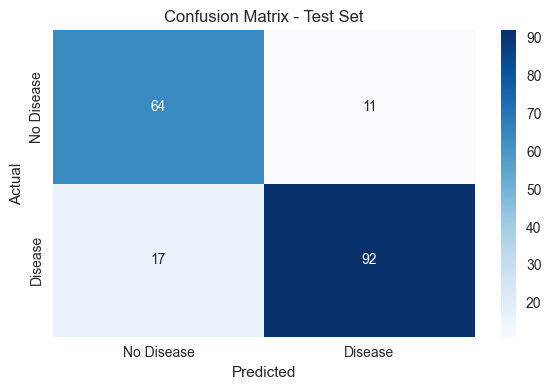

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

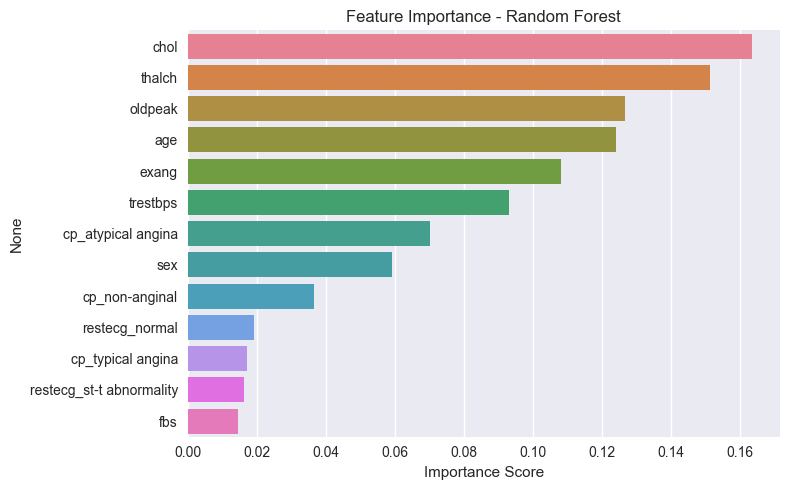

In [27]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, 
            hue=importances.index, palette='husl', legend=False)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [29]:
df.to_csv('data/heart_disease_cleaned.csv', index=False)

# Creating predictions dataframe
df_predictions = x_test.copy()
df_predictions['actual'] = y_test.values
df_predictions['predicted'] = y_pred_test

# Exporting predictions
df_predictions.to_csv('data/heart_disease_predictions.csv', index=False)

print('Files exported successfully! ✅')

Files exported successfully! ✅


In [30]:
import os
print(os.getcwd())

C:\Users\Luiza Magnani\Downloads\DataSciencePortfolio\03_ml_prediction
